<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L07-Modelos_ARIMA/notebooks/L07_4_ModelosSARIMAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pmdarima # Ojo: Después de la primera instalación se puede comentar esta línea

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Subir archivo co2.csv
from google.colab import files
files.upload()

Saving US_change_full.csv to US_change_full (4).csv


{'US_change_full (4).csv': b'Date,Consumption,Income,Production,Savings,Unemployment\r\n01/01/1970,0.6185664,1.044801332,-2.452485527,5.299014071,0.9\r\n01/04/1970,0.451984019,1.225647192,-0.551459474,7.789893824,0.5\r\n01/07/1970,0.87287178,1.585153835,-0.358651752,7.403984066,0.5\r\n01/10/1970,-0.271847933,-0.239544865,-2.185690872,1.169898242,0.7\r\n01/01/1971,1.901344959,1.975924949,1.909764364,3.535666928,-0.1\r\n01/04/1971,0.914877346,1.445908528,0.901569522,5.874763572,-0.1\r\n01/07/1971,0.794109641,0.521149113,0.308030708,-0.406235341,0.1\r\n01/10/1971,1.645633164,1.159176094,2.291362138,-1.486258902,0\r\n01/01/1972,1.311189694,0.456856714,4.154294954,-4.291972196,-0.2\r\n01/04/1972,1.885777877,1.033389307,1.888672712,-4.692196362,-0.1\r\n01/07/1972,1.529333612,1.9262949,1.265411446,5.92345399,-0.2\r\n01/10/1972,2.319557542,3.929949222,3.439587472,16.07351412,-0.3\r\n01/01/1973,1.809282167,0.755642728,2.794145253,-4.758983188,-0.3\r\n01/04/1973,-0.045090607,0.84039233,0.8321744

In [3]:
df = pd.read_csv('/content/US_change_full.csv')
df.head()

,Date,Consumption,Income,Production,Savings,Unemployment
0,01/01/1970,0.618566,1.044801,-2.452486,5.299014,0.9
1,01/04/1970,0.451984,1.225647,-0.551459,7.789894,0.5
2,01/07/1970,0.872872,1.585154,-0.358652,7.403984,0.5
3,01/10/1970,-0.271848,-0.239545,-2.185691,1.169898,0.7
4,01/01/1971,1.901345,1.975925,1.909764,3.535667,-0.1


In [4]:
df['Fecha'] = pd.period_range(start='1970-01', periods=len(df), freq='Q')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.head()

,Date,Consumption,Income,Production,Savings,Unemployment
Fecha,,,,,,
1970-01-01,01/01/1970,0.618566,1.044801,-2.452486,5.299014,0.9
1970-04-01,01/04/1970,0.451984,1.225647,-0.551459,7.789894,0.5
1970-07-01,01/07/1970,0.872872,1.585154,-0.358652,7.403984,0.5
1970-10-01,01/10/1970,-0.271848,-0.239545,-2.185691,1.169898,0.7
1971-01-01,01/01/1971,1.901345,1.975925,1.909764,3.535667,-0.1


In [5]:
fechaSplit = '2014-12-31'
dfTrain = df.loc[df.index <= fechaSplit]
dfTest = df.loc[df.index > fechaSplit]

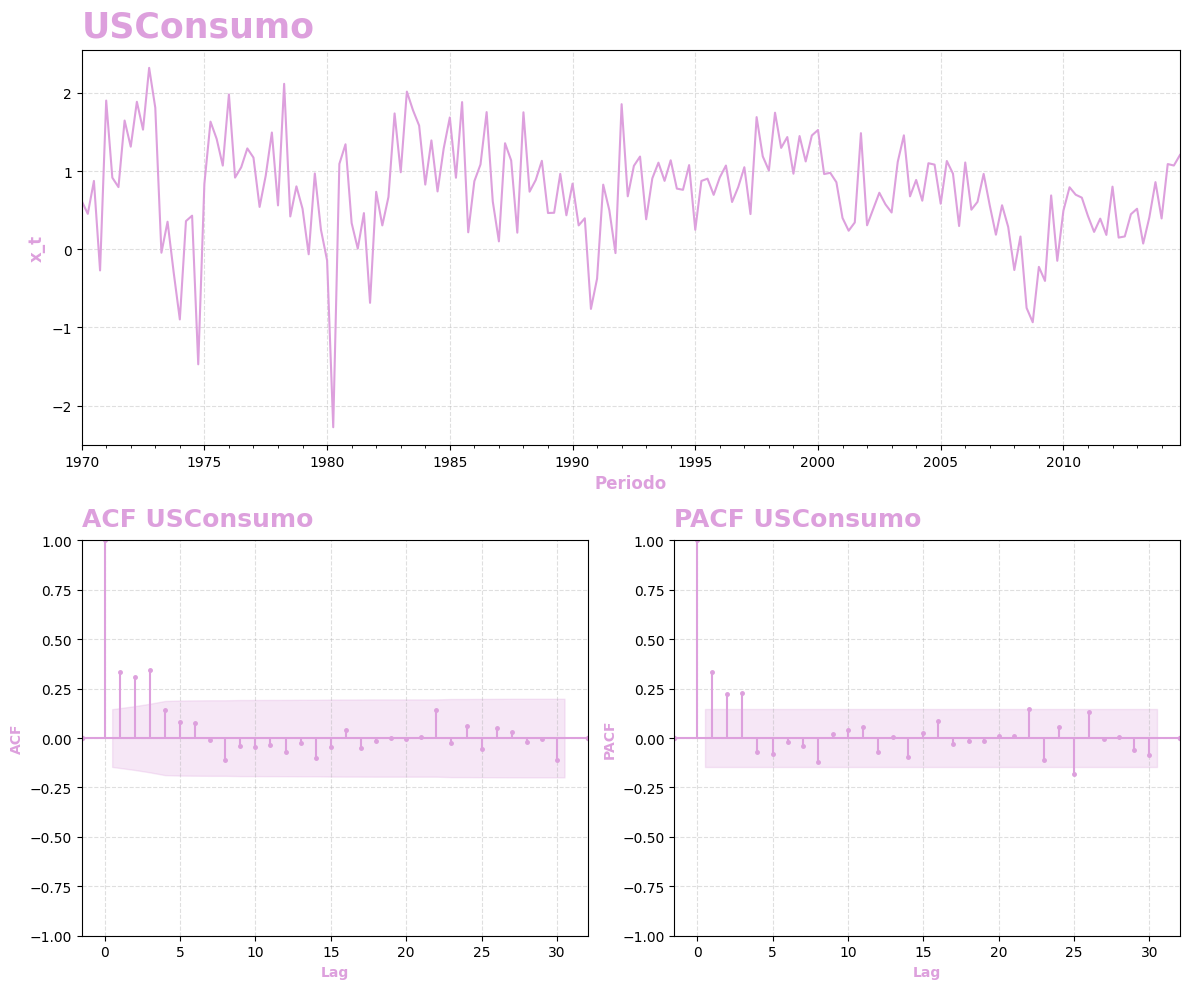

In [6]:
graphColor = 'plum'
columna = 'Consumption'
nombre = 'USConsumo'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
dfTrain[columna].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(dfTrain[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(dfTrain[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

## **Modelo SARIMA**

In [7]:
# Ajuste de un modelo SARIMA automático con p, q, P, Q de 0 a 5
# Si no se coloca orden para d, D la función los encuentra
sarimaConsumo = auto_arima(dfTrain[columna],
                              start_p=1, max_p=5,
                              start_q=1, max_q=5,
                              information_criterion = 'aic',
                              stepwise = True, # Prueba con algoritmo stepwise
                              with_intercept = True, # Que incluya un intercepto
                              # Parámetros de estacionalidad
                              seasonal=True,
                              m = 4,
                              start_P=1, max_P=5,
                              start_Q=1, max_Q=5
                              )

print(sarimaConsumo.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  180
Model:             SARIMAX(3, 0, 0)x(2, 0, 0, 4)   Log Likelihood                -159.154
Date:                           Sat, 27 Jun 2026   AIC                            332.307
Time:                                   07:44:43   BIC                            354.658
Sample:                               01-01-1970   HQIC                           341.369
                                    - 10-01-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3399      0.078      4.355      0.000       0.187       0.493
ar.L1          0.2039      0.062      3.290

In [8]:
# Obtener valores ajustados y predicciones
modelo = sarimaConsumo
pasos = len(dfTest) # Usar el tamaño de los datos de prueba como pasos
nombreSerie = 'Variación en tasa de Consumo en Estados Unidos'
nombreModelo = 'SARIMA (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0:5] = np.nan

# Generar predicciones con intervalos de confianza al 95%
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfForSarima = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfForSarima.head()

Fecha
1970-01-01   NaN
1970-04-01   NaN
1970-07-01   NaN
1970-10-01   NaN
1971-01-01   NaN
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2015-01-01,0.973177,-0.173125,2.119478
2015-04-01,1.015260,-0.154631,2.185151
2015-07-01,0.961402,-0.235567,2.158371
2015-10-01,0.823746,-0.428283,2.075775
2016-01-01,0.893569,-0.366843,2.153981


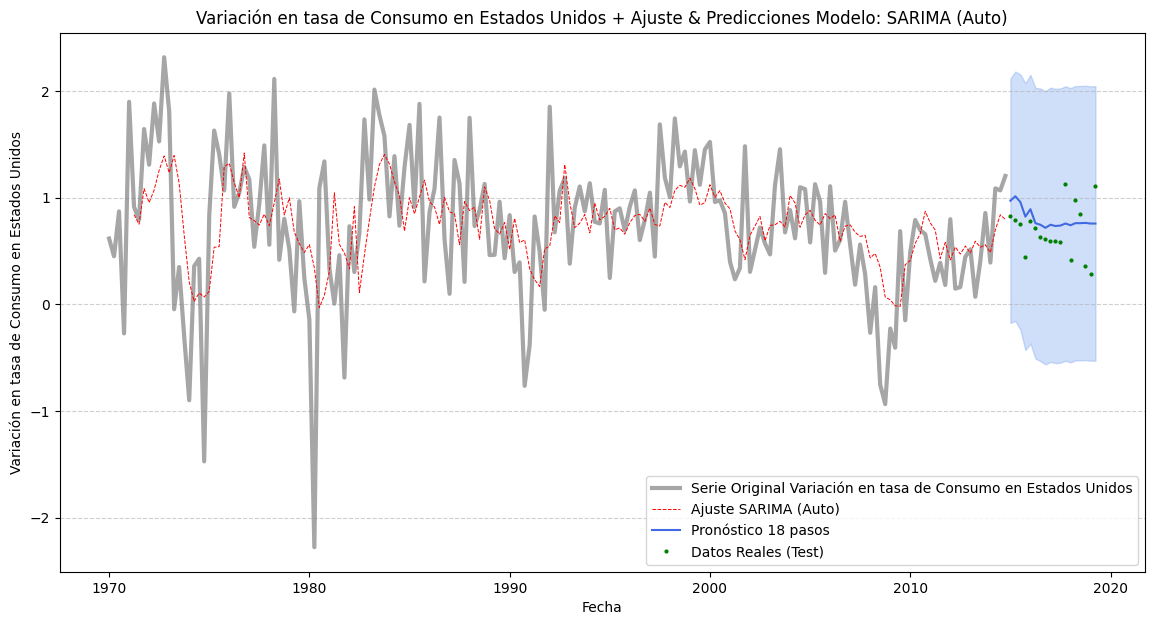

In [9]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original (dfTrain)
plt.plot(dfTrain.index, dfTrain[columna], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(dfTrain.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarima.index, dfForSarima['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Valores reales (Test Data) para comparación
plt.plot(dfTest.index, dfTest[columna], label='Datos Reales (Test)', color='green', marker='.', linestyle='none', markersize=4)
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarima.index, dfForSarima['cotaInf'], dfForSarima['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + 'SARIMA (Auto)')
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Modelo Sarimax Simple**

In [10]:
# Ajuste de un modelo SARIMA automático con p, q, P, Q de 0 a 5
# Si no se coloca orden para d, D la función los encuentra
sarimaxConsumoSimple = auto_arima(y = dfTrain[columna],
                                  X = dfTrain[['Unemployment']], # Variable Exógena! Doble Corchete para pasar un df y no una serie
                                  stepwise = False, # Prueba con algoritmo stepwise
                                  seasonal=True,
                                  m = 4
                                  )

print(sarimaxConsumoSimple.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  180
Model:             SARIMAX(3, 1, 0)x(0, 0, [1], 4)   Log Likelihood                -141.055
Date:                             Sat, 27 Jun 2026   AIC                            296.110
Time:                                     07:45:09   BIC                            318.421
Sample:                                 01-01-1970   HQIC                           305.157
                                      - 10-01-2014                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       -0.0129      0.018     -0.726      0.468      -0.048       0.022
Unemployment    -0.96

In [11]:
# Obtener valores ajustados y predicciones
modelo = sarimaxConsumoSimple
pasos = len(dfTest) # Usar el tamaño de los datos de prueba como pasos
nombreSerie = 'Variación en tasa de Consumo en Estados Unidos'
nombreModelo = 'SARIMAX Simple (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0:5] = np.nan

# Generar predicciones con intervalos de confianza al 95%
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True, X=dfTest[['Unemployment']])
dfForSarimaxSim = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfForSarimaxSim.head()

Fecha
1970-01-01   NaN
1970-04-01   NaN
1970-07-01   NaN
1970-10-01   NaN
1971-01-01   NaN
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2015-01-01,0.595500,-0.442514,1.633514
2015-04-01,0.564073,-0.480226,1.608371
2015-07-01,0.708598,-0.350381,1.767576
2015-10-01,0.322619,-0.767794,1.413032
2016-01-01,0.397983,-0.692486,1.488453


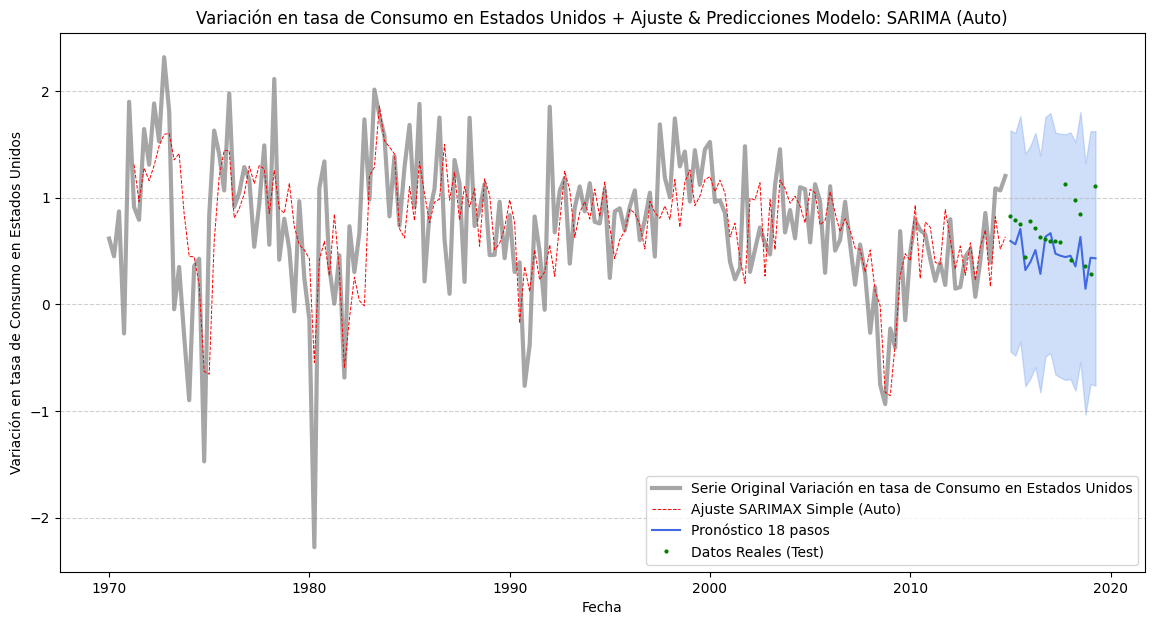

In [12]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original (dfTrain)
plt.plot(dfTrain.index, dfTrain[columna], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(dfTrain.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarimaxSim.index, dfForSarimaxSim['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Valores reales (Test Data) para comparación
plt.plot(dfTest.index, dfTest[columna], label='Datos Reales (Test)', color='green', marker='.', linestyle='none', markersize=4)
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarimaxSim.index, dfForSarimaxSim['cotaInf'], dfForSarimaxSim['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + 'SARIMA (Auto)')
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Modelo Sarimax Multiple**

In [13]:
# Ajuste de un modelo SARIMA automático con p, q, P, Q de 0 a 5
# Si no se coloca orden para d, D la función los encuentra
sarimaxConsumoMult = auto_arima(y = dfTrain[columna],
                                  X = dfTrain[['Unemployment', 'Income', 'Savings']], # Incluyendo múltiples variables exógenas
                                  stepwise = False, # Prueba con algoritmo stepwise
                                  seasonal=True,
                                  m = 4
                                  )

print(sarimaxConsumoMult.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  180
Model:               SARIMAX(1, 1, 2)   Log Likelihood                 -48.741
Date:                Sat, 27 Jun 2026   AIC                            113.482
Time:                        07:45:55   BIC                            138.981
Sample:                    01-01-1970   HQIC                           123.822
                         - 10-01-2014                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       -0.0021      0.001     -1.600      0.110      -0.005       0.000
Unemployment    -0.3376      0.054     -6.280      0.000      -0.443      -0.232
Income           0.7515      0.031     24.43

In [14]:
# Obtener valores ajustados y predicciones
modelo = sarimaxConsumoMult
pasos = len(dfTest) # Usar el tamaño de los datos de prueba como pasos
nombreSerie = 'Variación en tasa de Consumo en Estados Unidos'
nombreModelo = 'SARIMAX Multiple (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0:5] = np.nan

# Generar predicciones con intervalos de confianza al 95%
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True, X=dfTest[['Unemployment', 'Income', 'Savings']])
dfForSarimaxMult = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfForSarimaxMult.head()

Fecha
1970-01-01   NaN
1970-04-01   NaN
1970-07-01   NaN
1970-10-01   NaN
1971-01-01   NaN
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2015-01-01,0.884717,0.268179,1.501256
2015-04-01,0.741470,0.123217,1.359722
2015-07-01,0.802513,0.182159,1.422868
2015-10-01,0.490972,-0.130141,1.112085
2016-01-01,0.677402,0.055119,1.299684


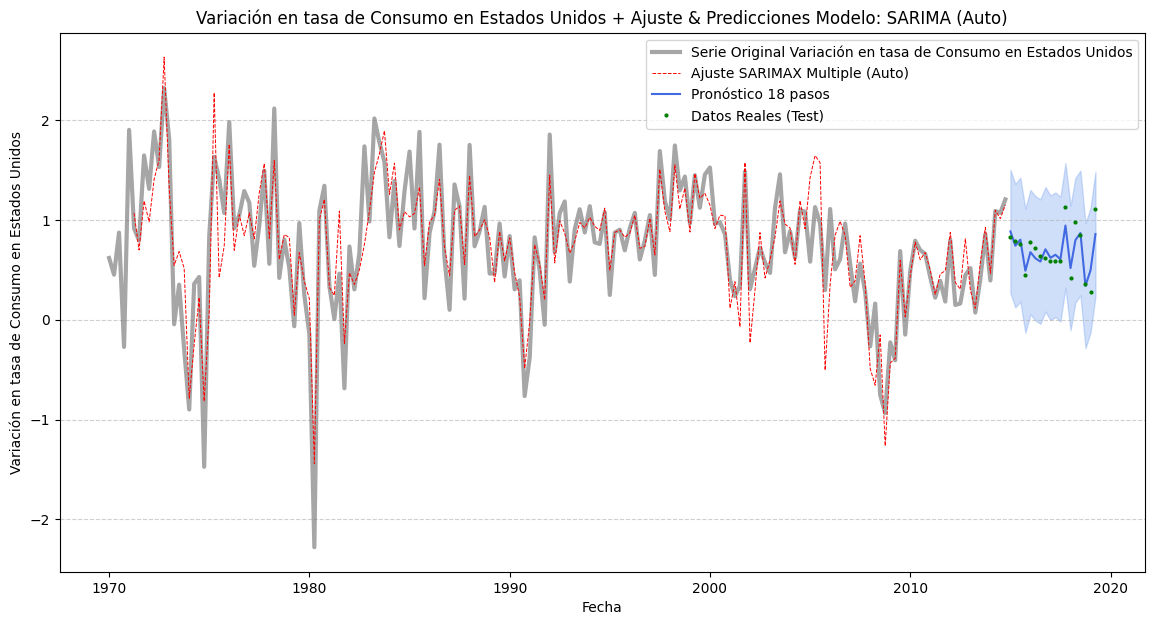

In [15]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original (dfTrain)
plt.plot(dfTrain.index, dfTrain[columna], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(dfTrain.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarimaxMult.index, dfForSarimaxMult['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Valores reales (Test Data) para comparación
plt.plot(dfTest.index, dfTest[columna], label='Datos Reales (Test)', color='green', marker='.', linestyle='none', markersize=4)
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarimaxMult.index, dfForSarimaxMult['cotaInf'], dfForSarimaxMult['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + 'SARIMA (Auto)')
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **SARIMAX Manual**

In [16]:
# Definir la variable exógena
exog_train = dfTrain[['Unemployment', 'Income', 'Savings']] # Changed to include multiple exogenous variables

# Definir el modelo SARIMAX con la variable exógena
sarimaxManual = SARIMAX(dfTrain[columna],
                             exog=exog_train,
                             order=(3, 0, 0), # Usando el orden del auto_arima inicial
                             seasonal_order=(2, 0, 0, 4), # Usando el orden estacional del auto_arima inicial
                             trend='c') # Incluir intercepto

# Ajustar el modelo
sarimaxManual = sarimaxManual.fit(maxiter=1000)

print(sarimaxManual.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       Consumption   No. Observations:                  180
Model:             SARIMAX(3, 0, 0)x(2, 0, 0, 4)   Log Likelihood                 -47.920
Date:                           Sat, 27 Jun 2026   AIC                            115.840
Time:                                   07:45:56   BIC                            147.769
Sample:                               01-01-1970   HQIC                           128.786
                                    - 10-01-2014                                         
Covariance Type:                             opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        0.2820      0.049      5.761      0.000       0.186       0.378
Unemployment    -0.2970      0.060   

In [17]:
# Obtener valores ajustados y predicciones
modelo = sarimaxManual # Use the newly fitted manual SARIMAX model with exog variables
pasos = len(dfTest) # Use length of test data for forecast steps
nombreSerie = 'Variación en tasa de Consumo en Estados Unidos'
nombreModelo = 'SARIMAX Manual (Multi-Exógeno)' # Updated model name

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0:13] = np.nan

# Generar predicciones con intervalos de confianza al 95%
prediction_results = modelo.get_forecast(steps=pasos, exog=dfTest[['Unemployment', 'Income', 'Savings']]) # Pass multiple exogenous variables to get_forecast
forecast_sarimax_exog_manual = prediction_results.predicted_mean
conf_intervals_sarimax_exog_manual = prediction_results.conf_int(alpha=0.05)
intConf_sarimax_exog_manual = conf_intervals_sarimax_exog_manual.values

dfForSarimaxManual = pd.DataFrame({
    'forecast': forecast_sarimax_exog_manual,
    'cotaInf': intConf_sarimax_exog_manual[:, 0],
    'cotaSup': intConf_sarimax_exog_manual[:, 1]
})

print(valoresAjuste.head())
dfForSarimaxManual.head()

Fecha
1970-01-01   NaN
1970-04-01   NaN
1970-07-01   NaN
1970-10-01   NaN
1971-01-01   NaN
Freq: QS-OCT, dtype: float64


,forecast,cotaInf,cotaSup
2015-01-01,1.008815,0.390117,1.627512
2015-04-01,0.847851,0.227012,1.468689
2015-07-01,0.891330,0.267439,1.515221
2015-10-01,0.591197,-0.038174,1.220568
2016-01-01,0.776583,0.147212,1.405954


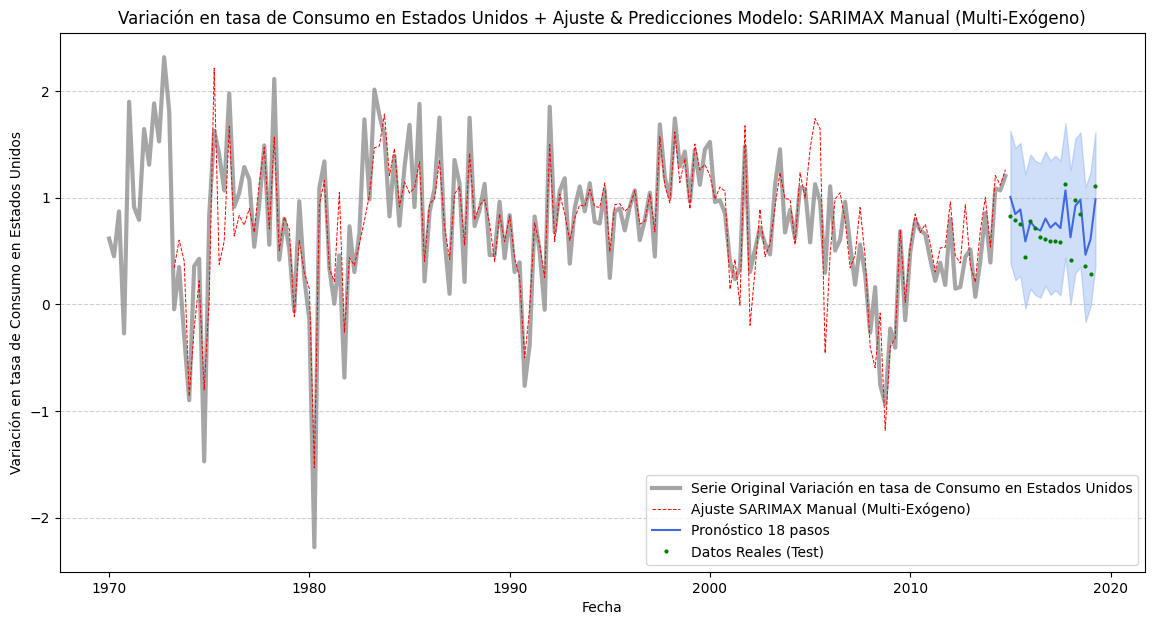

In [18]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original (dfTrain)
plt.plot(dfTrain.index, dfTrain[columna], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados (dfTrain)
plt.plot(dfTrain.index, valoresAjuste, label='Ajuste SARIMAX Manual (Multi-Exógeno)', color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarimaxManual.index, dfForSarimaxManual['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Valores reales (Test Data) para comparación
plt.plot(dfTest.index, dfTest[columna], label='Datos Reales (Test)', color='green', marker='.', linestyle='none', markersize=4)
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarimaxManual.index, dfForSarimaxManual['cotaInf'], dfForSarimaxManual['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + 'SARIMAX Manual (Multi-Exógeno)')
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Desempeño de Modelos**

In [19]:
def metricasPrecision(real, pronostico, trainData, estacionalidad=12):
      resultados = {}

      # ME - Mean Error
      resultados['ME'] = np.mean(pronostico - real)

      # MAE - Mean Absolute Error
      resultados['MAE'] = mean_absolute_error(real, pronostico)

      # MSE - Mean Squared Error
      resultados['MSE'] = mean_squared_error(real, pronostico)

      # RMSE - Root Mean Squared Error
      resultados['RMSE'] = np.sqrt(mean_squared_error(real, pronostico))

      # Preparar para MPE y MAPE: manejar la división por cero
      # Reemplazar 0s con NaN para evitar la división por cero, luego filtrar NaNs
      realSinCero = real.replace(0, np.nan)
      realSinCero = realSinCero[realSinCero.notna()]
      pronosticoSinCero = pronostico[realSinCero.notna()]

      # MPE - Mean Percentage Error
      if len(realSinCero) > 0:
          resultados['MPE'] = np.mean(((realSinCero - pronosticoSinCero) / realSinCero)) * 100
      else:
          resultados['MPE'] = np.nan

      # MAPE - Mean Absolute Percentage Error
      if len(realSinCero) > 0:
          resultados['MAPE'] = np.mean(np.abs((realSinCero - pronosticoSinCero) / realSinCero)) * 100
      else:
          resultados['MAPE'] = np.nan

      # Para MASE y RMSSE, necesitamos calcular el factor de escala basado en naive
      # trainData es df['x']

      if len(trainData) > estacionalidad:
          patronEstacional = trainData.iloc[-estacionalidad:]
          pasos = len(real)
          naive = list(patronEstacional) * (pasos // estacionalidad) + list(patronEstacional)[0:(pasos % estacionalidad)]

          # Denominador para MASE
          MAENaive = mean_absolute_error(real, naive)

          # Denominador para RMSE
          RMSENaive = np.sqrt(mean_squared_error(real, naive))

          # 6. Error Absoluto Escalonado Medio (MASE)
          if MAENaive > 0:
              resultados['MASE'] = resultados['MAE'] / MAENaive
          else:
              resultados['MASE'] = np.inf if resultados['MAE'] > 0 else 0

          # 7. Raíz del Error Cuadrático Medio Escalonado (RMSSE)
          if RMSENaive > 0:
              resultados['RMSSE'] = resultados['RMSE'] / RMSENaive
          else:
              resultados['RMSSE'] = np.inf if resultados['RMSE'] > 0 else 0
      else:
          resultados['MASE'] = np.nan
          resultados['RMSSE'] = np.nan

      return resultados

In [20]:
# --- Calcular y mostrar métricas para cada modelo ---
dfReal = dfTest[columna] # Use dfTest for real values
resultados_metricas = {}

# Metrics for SARIMA Auto model
resultados_metricas['SARIMA Auto'] = metricasPrecision(dfReal, dfForSarima['forecast'], dfTrain[columna])

# Metrics for SARIMAX Simple (Auto) model
resultados_metricas['SARIMAX Simple (Auto)'] = metricasPrecision(dfReal, dfForSarimaxSim['forecast'], dfTrain[columna])

# Metrics for SARIMAX Multiple (Auto) model
resultados_metricas['SARIMAX Multiple (Auto)'] = metricasPrecision(dfReal, dfForSarimaxMult['forecast'], dfTrain[columna])

# Metrics for SARIMAX Manual (Multi-Exógeno) model
resultados_metricas['SARIMAX Manual (Multi-Exógeno)'] = metricasPrecision(dfReal, dfForSarimaxManual['forecast'], dfTrain[columna])

# Convertir a DataFrame para una mejor visualización
df_metricas = pd.DataFrame.from_dict(resultados_metricas, orient='index')
df_metricas.round(4)

,ME,MAE,MSE,RMSE,MPE,MAPE,MASE,RMSSE
SARIMA Auto,0.1082,0.2236,0.0657,0.2563,-30.6628,41.5331,0.5613,0.5208
SARIMAX Simple (Auto),-0.2196,0.2516,0.1065,0.3264,25.3100,34.2043,0.6315,0.6633
SARIMAX Multiple (Auto),-0.0157,0.0898,0.0131,0.1144,-2.8452,14.4482,0.2254,0.2324
SARIMAX Manual (Multi-Exógeno),0.0957,0.1233,0.0212,0.1455,-21.1862,23.7305,0.3095,0.2956


¿Cuál tiene mejor desempeño?

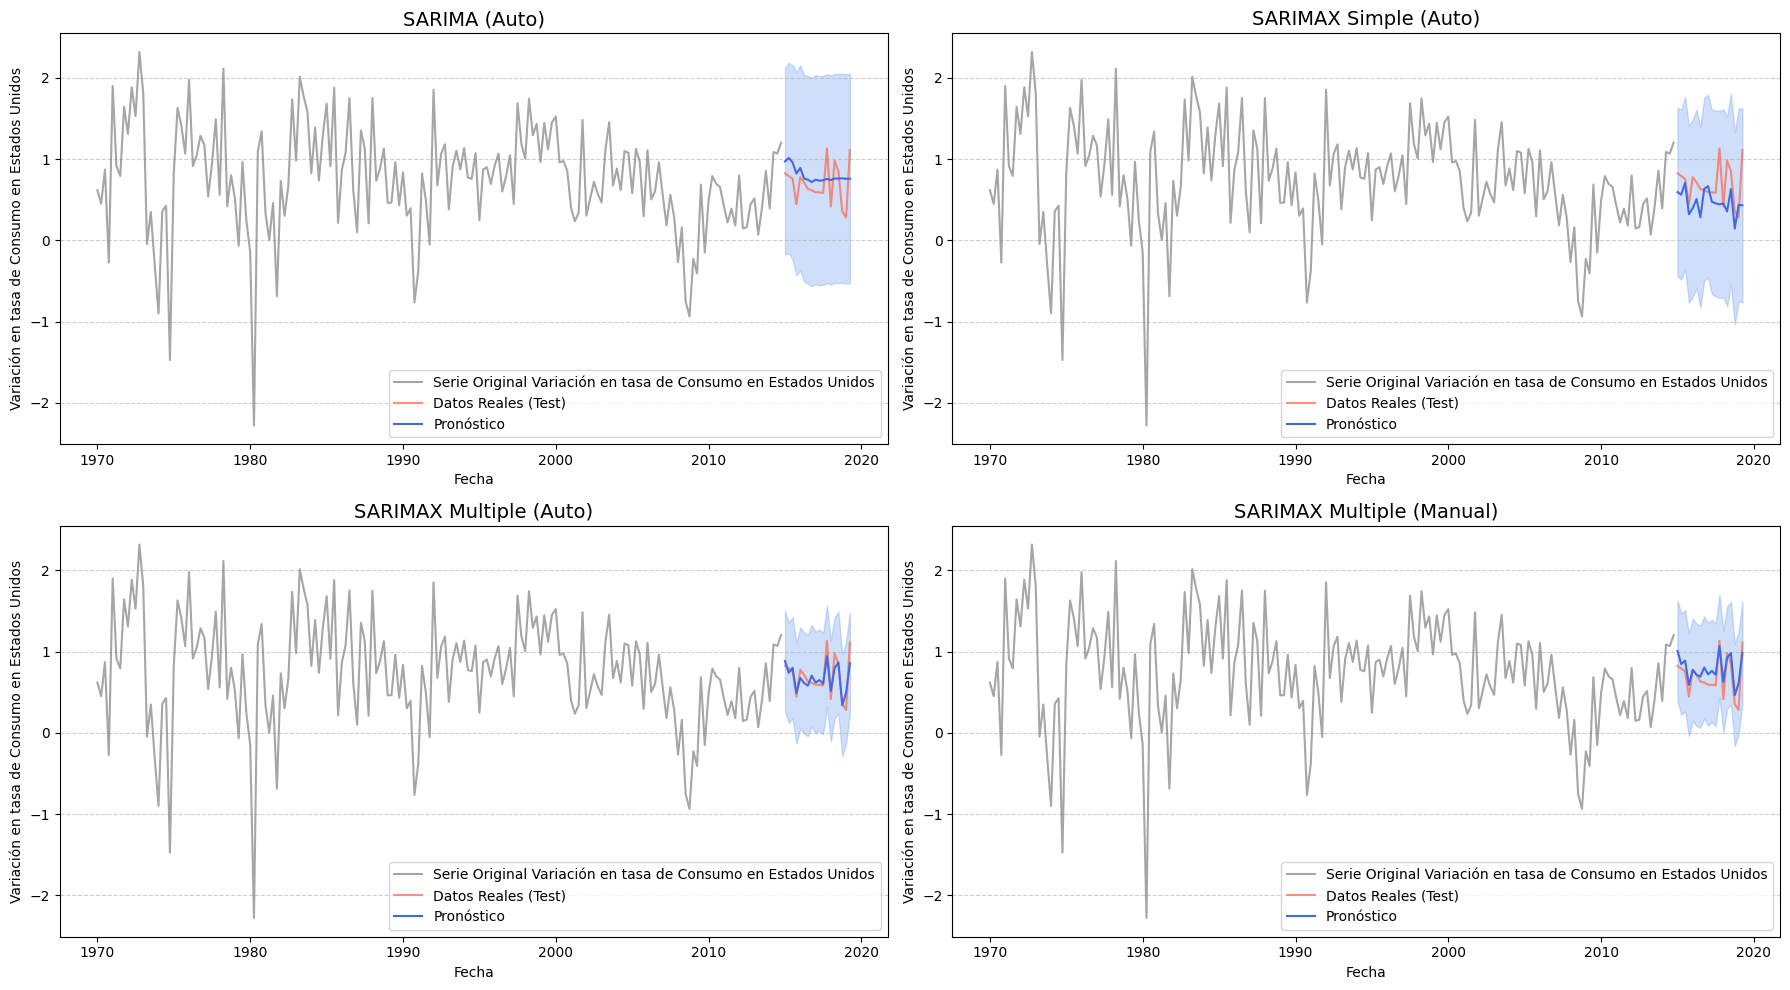

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

# Helper function to plot for each model
def graficoForecast(ax, df_forecast, tituloGraf):
    ax.plot(dfTrain.index, dfTrain[columna], label='Serie Original ' + nombreSerie, color='gray', alpha=0.7)
    ax.plot(dfTest.index, dfTest[columna], label='Datos Reales (Test)', color='tomato', lw=1.5, alpha=0.7)
    ax.plot(df_forecast.index, df_forecast['forecast'], label='Pronóstico', color='royalblue')
    ax.fill_between(df_forecast.index, df_forecast['cotaInf'], df_forecast['cotaSup'], color='cornflowerblue', alpha=0.3)
    ax.set_title(tituloGraf, fontsize=14)
    ax.set_xlabel('Fecha')
    ax.set_ylabel(nombreSerie)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# --- Plot SARIMA (Auto) ---
graficoForecast(axes[0], dfForSarima, 'SARIMA (Auto)')

# --- Plot SARIMAX Simple (Auto) ---
graficoForecast(axes[1], dfForSarimaxSim, 'SARIMAX Simple (Auto)')

# --- Plot SARIMAX Multiple (Auto) ---
graficoForecast(axes[2], dfForSarimaxMult, 'SARIMAX Multiple (Auto)')

# --- Plot SARIMAX Manual (Multi-Exógeno) ---
graficoForecast(axes[3], dfForSarimaxManual, 'SARIMAX Multiple (Manual)')

plt.tight_layout()
plt.show()